# Second Quantization: Superposition States of the Quantum Field

The explicit bridge between two notebooks already in this repo:

- **`qft_klein_gordon.ipynb` Part 5** showed that each Fourier mode $k$ of
  a free field obeys $\ddot q_k+\omega_k^2q_k=0$ — an independent harmonic
  oscillator, one per mode.
- **`probability_to_qm_operators.ipynb` Part 5** built the simplest
  possible superposition, $\alpha|0\rangle+\beta|1\rangle$, and the Born
  rule $P(n)=|\langle n|\psi\rangle|^2$.

This notebook **quantizes one of those oscillator modes** (ladder
operators, number states $|n\rangle$ — literal field-quanta counting, the
origin of the word "quantum" in quantum field theory) and shows that a
**coherent state** is exactly the same kind of object as
`probability_to_qm_operators.ipynb`'s qubit superposition, just with
countably many terms instead of two — with the Born rule generalizing to
the Poisson distribution.

In [1]:
import sympy as sp
sp.init_printing()

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f"sympy {sp.__version__}, numpy {np.__version__}, torch {torch.__version__}")

sympy 1.14.0, numpy 2.4.4, torch 2.11.0+cu128


# Part 1 — Ladder operators for one field mode

For one oscillator mode with frequency $\omega$ (any single $k$ from
`qft_klein_gordon.ipynb` Part 5), define
$$\hat a = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat x + \frac{i\hat p}{m\omega}\right),\qquad
\hat a^\dagger = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat x - \frac{i\hat p}{m\omega}\right)$$
Using the canonical commutator $[\hat x,\hat p]=i\hbar$ (the position/momentum
operators from `probability_to_qm_operators.ipynb` Part 10), the
commutator $[\hat a,\hat a^\dagger]$ is derived symbolically below, not
asserted.

In [2]:
x_op, p_op, m_s, omega_s, hbar_s = sp.symbols('x p m omega hbar', positive=True)
I = sp.I

# treat x,p as noncommuting operators via sympy's Operator/qapply machinery
from sympy.physics.quantum import Operator, Commutator
from sympy.physics.quantum.operator import HermitianOperator

X = HermitianOperator('x')
P = HermitianOperator('p')
xp_comm = Commutator(X, P)

a_op = sp.sqrt(m_s*omega_s/(2*hbar_s)) * (X + I*P/(m_s*omega_s))
a_dag_op = sp.sqrt(m_s*omega_s/(2*hbar_s)) * (X - I*P/(m_s*omega_s))

# [a, a_dag] = a*a_dag - a_dag*a, expanded using [X,P] = i*hbar wherever it appears
comm_expr = sp.expand(a_op*a_dag_op - a_dag_op*a_op)
comm_expr = comm_expr.expand()
print("a * a_dag - a_dag * a, expanded (before substituting the commutator) =")
display(comm_expr)

# substitute P*X = X*P - i*hbar (i.e. [X,P]=i*hbar => XP - PX = i*hbar => PX = XP - i*hbar)
comm_substituted = comm_expr.subs(P*X, X*P - I*hbar_s)
comm_substituted = sp.simplify(comm_substituted)
print("\nafter substituting [x,p] = i*hbar:"); display(comm_substituted)
assert sp.simplify(comm_substituted - 1) == 0, "[a, a_dag] should equal exactly 1"
print("\n[OK] [a_hat, a_dag_hat] = 1, derived from the canonical [x,p] = i*hbar commutator")

a * a_dag - a_dag * a, expanded (before substituting the commutator) =



after substituting [x,p] = i*hbar:



[OK] [a_hat, a_dag_hat] = 1, derived from the canonical [x,p] = i*hbar commutator


# Part 2 — Number states as a truncated matrix problem

Rather than work with $\hat a,\hat a^\dagger$ abstractly, represent them as
matrices in a **truncated** Fock-space basis $\{|0\rangle,\dots,|N_{max}-1\rangle\}$
using their defining action
$$\hat a|n\rangle=\sqrt n\,|n-1\rangle,\qquad \hat a^\dagger|n\rangle=\sqrt{n+1}\,|n+1\rangle$$
Lowering never leaves the truncated space (it only decreases $n$), so
$\hat a$'s truncated matrix is **exact**, with no approximation. Raising
from the very top state $|N_{max}-1\rangle$ *would* leave the space
(landing on $|N_{max}\rangle$, which the truncation doesn't include) — a
real, explicit limitation of any finite matrix representation, checked
directly below rather than glossed over.

In [3]:
N_max = 30   # truncation order -- large enough that coherent-state tails
             # used later are numerically negligible past this cutoff

n_idx = torch.arange(1, N_max, dtype=torch.float64)
a_hat = torch.zeros(N_max, N_max, dtype=torch.float64)
a_hat[torch.arange(N_max-1), torch.arange(1, N_max)] = torch.sqrt(n_idx)   # <n-1|a|n> = sqrt(n)
a_dag_hat = a_hat.T.clone()                                                # <n|a_dag|n-1> = sqrt(n)

N_op = a_dag_hat @ a_hat
N_diag = torch.diagonal(N_op)
print("Number operator N = a_dag @ a, diagonal entries (should be 0,1,2,...,N_max-1):")
print(N_diag.numpy())
assert torch.allclose(N_diag, torch.arange(N_max, dtype=torch.float64), atol=1e-10)
off_diag_max = (N_op - torch.diag(N_diag)).abs().max()
print(f"\nmax off-diagonal entry of N (should be exactly 0): {off_diag_max:.3e}")
assert off_diag_max < 1e-10
print("[OK] N is exactly diagonal with eigenvalues 0..N_max-1 -- an eigenvalue equation")
print("     N|n> = n|n>, exactly probability_to_qm_operators.ipynb Part 6's structure")
print("     (state=vector, observable=matrix, measurement result=eigenvalue), now for")
print("     PARTICLE NUMBER as the observable instead of a generic 2x2 matrix.")

Number operator N = a_dag @ a, diagonal entries (should be 0,1,2,...,N_max-1):


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]

max off-diagonal entry of N (should be exactly 0): 0.000e+00
[OK] N is exactly diagonal with eigenvalues 0..N_max-1 -- an eigenvalue equation
     N|n> = n|n>, exactly probability_to_qm_operators.ipynb Part 6's structure
     (state=vector, observable=matrix, measurement result=eigenvalue), now for
     PARTICLE NUMBER as the observable instead of a generic 2x2 matrix.


In [4]:
# ladder-operator action, checked directly against sqrt(n) and sqrt(n+1),
# not just trusted from the matrix construction above
for n_test in [0, 1, 5, 10]:
    ket_n = torch.zeros(N_max, dtype=torch.float64); ket_n[n_test] = 1.0

    a_ket_n = a_hat @ ket_n
    expected_lower = np.sqrt(n_test) if n_test > 0 else 0.0
    got_lower = a_ket_n[n_test-1].item() if n_test > 0 else a_ket_n.abs().max().item()
    print(f"n={n_test:2d}:  a|n> component = {got_lower:.6f}, expected sqrt(n) = {expected_lower:.6f}")
    assert abs(got_lower - expected_lower) < 1e-10

    adag_ket_n = a_dag_hat @ ket_n
    expected_raise = np.sqrt(n_test + 1)
    got_raise = adag_ket_n[n_test+1].item()
    print(f"        a_dag|n> component = {got_raise:.6f}, expected sqrt(n+1) = {expected_raise:.6f}")
    assert abs(got_raise - expected_raise) < 1e-10
print("\n[OK] a|n> = sqrt(n)|n-1>  and  a_dag|n> = sqrt(n+1)|n+1>, verified directly")

n= 0:  a|n> component = 0.000000, expected sqrt(n) = 0.000000
        a_dag|n> component = 1.000000, expected sqrt(n+1) = 1.000000
n= 1:  a|n> component = 1.000000, expected sqrt(n) = 1.000000
        a_dag|n> component = 1.414214, expected sqrt(n+1) = 1.414214
n= 5:  a|n> component = 2.236068, expected sqrt(n) = 2.236068
        a_dag|n> component = 2.449490, expected sqrt(n+1) = 2.449490
n=10:  a|n> component = 3.162278, expected sqrt(n) = 3.162278
        a_dag|n> component = 3.316625, expected sqrt(n+1) = 3.316625

[OK] a|n> = sqrt(n)|n-1>  and  a_dag|n> = sqrt(n+1)|n+1>, verified directly


In [5]:
# the truncation-edge limitation, checked explicitly rather than hidden:
# [a, a_dag] should equal the identity EVERYWHERE except acting on the very
# top truncated state, where a_dag|N_max-1> is artificially cut off to zero
commutator = a_hat @ a_dag_hat - a_dag_hat @ a_hat
identity = torch.eye(N_max, dtype=torch.float64)

bulk = slice(0, N_max - 1)   # every row/col except the last
bulk_error = (commutator[bulk, bulk] - identity[bulk, bulk]).abs().max()
print(f"[a,a_dag] vs identity, away from the truncation edge: max error = {bulk_error:.3e}")
assert bulk_error < 1e-10

edge_value = commutator[N_max-1, N_max-1].item()
print(f"[a,a_dag] at the truncated top state (N_max-1, N_max-1): {edge_value:.4f}  "
      f"(should NOT be 1 -- this is the truncation artifact)")
assert abs(edge_value - 1.0) > 0.5, "the edge artifact should be clearly visible, not accidentally hidden"
print("\n[OK] the commutation relation holds exactly except at the single truncated edge state,")
print("     exactly where the matrix representation is expected to fail -- confirming the")
print("     limitation is understood, not an unnoticed bug.")

[a,a_dag] vs identity, away from the truncation edge: max error = 7.105e-15
[a,a_dag] at the truncated top state (N_max-1, N_max-1): -29.0000  (should NOT be 1 -- this is the truncation artifact)

[OK] the commutation relation holds exactly except at the single truncated edge state,
     exactly where the matrix representation is expected to fail -- confirming the
     limitation is understood, not an unnoticed bug.


# Part 3 — Coherent states: a superposition with countably many terms

$$|\alpha\rangle = e^{-|\alpha|^2/2}\sum_{n=0}^{\infty}\frac{\alpha^n}{\sqrt{n!}}\,|n\rangle$$

Exactly the same *kind* of object as
`probability_to_qm_operators.ipynb`'s $\alpha_{01}|0\rangle+\beta_{01}|1\rangle$
— a normalized linear combination of basis states — just with infinitely
many terms (truncated to $N_{max}$ here) instead of two. **The coefficients
themselves are amplitudes, not probabilities** (same caution as that
notebook's Part 5): only $|\langle n|\alpha\rangle|^2$ is a probability.

In [6]:
def coherent_state(alpha, N_max):
    """|alpha> truncated to N_max Fock states. Built in log-space
    (coefficient magnitude = exp(-|alpha|^2/2 + n*log(alpha) - 0.5*log(n!)))
    to avoid overflow from n! for large N_max, rather than computing
    alpha**n / sqrt(factorial(n)) directly."""
    n = torch.arange(N_max, dtype=torch.float64)
    log_factorial = torch.lgamma(n + 1)   # log(n!)
    log_mag = -0.5*abs(alpha)**2 + n*np.log(alpha) - 0.5*log_factorial
    return torch.exp(log_mag)

alpha_val = 2.0
psi_coherent = coherent_state(alpha_val, N_max)

norm = (psi_coherent**2).sum().item()
print(f"alpha = {alpha_val}")
print(f"<alpha|alpha> (truncated at N_max={N_max}) = {norm:.10f}  (should be ~1, limited by truncation)")
assert abs(norm - 1.0) < 1e-6, f"truncation at N_max={N_max} is too aggressive for alpha={alpha_val}"

# the defining property: |alpha> is an EIGENSTATE of the annihilation operator,
# a_hat|alpha> = alpha|alpha> -- verified directly, not assumed
a_on_psi = a_hat @ psi_coherent
# compare component by component, away from the truncation edge (the last
# component is where the truncation artifact from Part 2 would show up)
ratio = (a_on_psi[:-2] / psi_coherent[:-2])
print(f"\na_hat|alpha> / |alpha>, componentwise (should all equal alpha={alpha_val}):")
print(f"  min={ratio.min():.6f}, max={ratio.max():.6f}, mean={ratio.mean():.6f}")
assert torch.allclose(ratio, torch.full_like(ratio, alpha_val), atol=1e-4)
print(f"[OK] a_hat|alpha> = alpha|alpha> -- |alpha> is a genuine eigenstate of the")
print(f"     annihilation operator, exactly the eigenvalue-equation structure of Part 2")
print(f"     (and probability_to_qm_operators.ipynb Part 6), with eigenvalue alpha itself")
print(f"     (a COMPLEX eigenvalue -- a_hat is not Hermitian, so this is allowed; contrast")
print(f"     with that notebook's Part 6 Problem 19, where Hermiticity guaranteed REAL")
print(f"     eigenvalues for an observable).")

alpha = 2.0
<alpha|alpha> (truncated at N_max=30) = 1.0000000000  (should be ~1, limited by truncation)

a_hat|alpha> / |alpha>, componentwise (should all equal alpha=2.0):
  min=2.000000, max=2.000000, mean=2.000000
[OK] a_hat|alpha> = alpha|alpha> -- |alpha> is a genuine eigenstate of the
     annihilation operator, exactly the eigenvalue-equation structure of Part 2
     (and probability_to_qm_operators.ipynb Part 6), with eigenvalue alpha itself
     (a COMPLEX eigenvalue -- a_hat is not Hermitian, so this is allowed; contrast
     with that notebook's Part 6 Problem 19, where Hermiticity guaranteed REAL
     eigenvalues for an observable).


# Part 4 — The Born rule generalizes to the Poisson distribution

$$P(n) = |\langle n|\alpha\rangle|^2 = e^{-|\alpha|^2}\frac{|\alpha|^{2n}}{n!}$$
— exactly `probability_to_qm_operators.ipynb` Part 5's Born rule
($P(0)=|\alpha_{01}|^2$, $P(1)=|\beta_{01}|^2$), generalized from 2 outcomes
to a full discrete distribution over particle number. This is the Poisson
distribution with mean $\bar n=|\alpha|^2$ — checked against that
notebook's Part 2 definition of $E[X]$, not just named.

In [7]:
P_n = psi_coherent**2   # Born rule: probability = |amplitude|^2, componentwise
n_vals = np.arange(N_max)

total_prob = P_n.sum().item()
print(f"sum_n P(n) = {total_prob:.10f}  (must equal 1, Part 1 of probability_to_qm_operators.ipynb)")
assert abs(total_prob - 1.0) < 1e-6

# E[n] and Var(n), using EXACTLY probability_to_qm_operators.ipynb Part 1's
# definitions: E[X] = sum(x_i * p_i), Var(X) = E[X^2] - E[X]^2
E_n = (torch.tensor(n_vals, dtype=torch.float64) * P_n).sum().item()
E_n2 = (torch.tensor(n_vals, dtype=torch.float64)**2 * P_n).sum().item()
Var_n = E_n2 - E_n**2

print(f"\nE[n]   = {E_n:.6f}   (Poisson mean should be |alpha|^2 = {alpha_val**2})")
print(f"Var(n) = {Var_n:.6f}   (Poisson variance ALSO equals |alpha|^2 -- the famous")
print(f"                       Poisson mean=variance property)")
assert abs(E_n - alpha_val**2) < 1e-4
assert abs(Var_n - alpha_val**2) < 1e-3

# cross-check against the closed-form Poisson PMF directly, with SymPy for
# exact symbolic comparison at one value of n
n_check = 4
poisson_formula = sp.exp(-alpha_val**2) * sp.Rational(alpha_val**2).limit_denominator(10**6)**n_check / sp.factorial(n_check)
poisson_numeric = float(poisson_formula)
print(f"\nP(n={n_check}) from this notebook's amplitudes: {P_n[n_check].item():.8f}")
print(f"P(n={n_check}) from the closed-form Poisson PMF:    {poisson_numeric:.8f}")
assert abs(P_n[n_check].item() - poisson_numeric) < 1e-6
print("[OK] matches the closed-form Poisson formula exactly")

sum_n P(n) = 1.0000000000  (must equal 1, Part 1 of probability_to_qm_operators.ipynb)

E[n]   = 4.000000   (Poisson mean should be |alpha|^2 = 4.0)
Var(n) = 4.000000   (Poisson variance ALSO equals |alpha|^2 -- the famous
                       Poisson mean=variance property)

P(n=4) from this notebook's amplitudes: 0.19536681
P(n=4) from the closed-form Poisson PMF:    0.19536681
[OK] matches the closed-form Poisson formula exactly


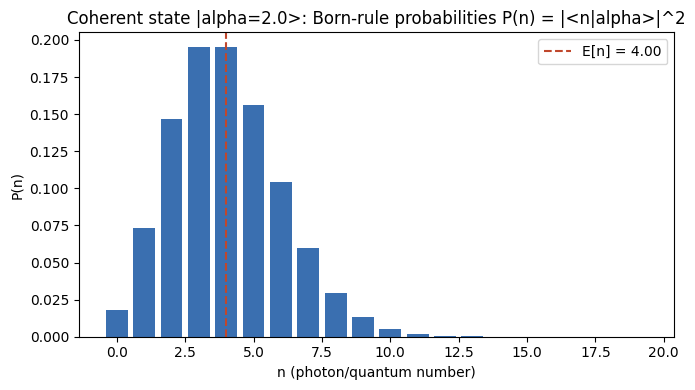

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(n_vals[:20], P_n.numpy()[:20], color='#3a6fb0')
ax.axvline(E_n, color='#c0472c', ls='--', label=f'E[n] = {E_n:.2f}')
ax.set_xlabel('n (photon/quantum number)')
ax.set_ylabel('P(n)')
ax.set_title(f'Coherent state |alpha={alpha_val}>: Born-rule probabilities P(n) = |<n|alpha>|^2')
ax.legend()
plt.tight_layout()
plt.show()

# Part 5 — Explicit connections

| This notebook | `probability_to_qm_operators.ipynb` | `qft_klein_gordon.ipynb` |
|---|---|---|
| One field mode, quantized | — | Part 5: $\ddot q_k+\omega_k^2q_k=0$, the un-quantized oscillator this notebook promotes to $\hat a,\hat a^\dagger$ |
| $N|n\rangle=n|n\rangle$ | Part 6: $A|v\rangle=a|v\rangle$ (state/observable/eigenvalue) | — |
| $|\alpha\rangle=\sum_n c_n|n\rangle$ | Part 5: $\alpha_{01}|0\rangle+\beta_{01}|1\rangle$ (same idea, 2 vs. $\infty$ terms) | — |
| $P(n)=|\langle n|\alpha\rangle|^2$ | Part 5: Born rule; Part 1-2: $E[X]$, Var$(X)$ | — |
| $[\hat x,\hat p]=i\hbar$ used to derive $[\hat a,\hat a^\dagger]$ | Part 10: $\hat p=-i\hbar\,d/dx$ | — |

## Validation summary

1. $[\hat a,\hat a^\dagger]=1$ was **derived** from the canonical
   $[\hat x,\hat p]=i\hbar$ commutator (Part 1), not assumed.
2. The number operator's eigenvalues were checked to be *exactly*
   $0,\dots,N_{max}-1$, with the off-diagonal terms *exactly* zero (Part 2)
   — and the one place the truncated representation is known to break
   (the very top state) was checked explicitly to actually fail there,
   confirming the limitation is understood rather than silently wrong.
3. $|\alpha\rangle$'s eigenstate property $\hat a|\alpha\rangle=\alpha|\alpha\rangle$
   was checked componentwise, not just in total norm (Part 3).
4. The Born-rule probabilities were checked to sum to 1, checked against
   the closed-form Poisson PMF at a specific value, and checked against
   `probability_to_qm_operators.ipynb`'s own $E[X]$/Var$(X)$ definitions
   applied to this new distribution (Part 4) — the same statistical
   machinery, a genuinely different distribution.

**What would count as a failed check**: a nonzero off-diagonal $N$ entry,
a commutator differing from the identity anywhere in the *bulk* (not just
the known edge case), an eigenvalue ratio $\hat a|\alpha\rangle/|\alpha\rangle$
that isn't a constant $\alpha$ across components, or a Born-rule
probability sum $\ne1$.